In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE,
    FIGURE_SIZE_HALF,
    LINE_STYLE,
    MARKER_STYLE,
    GRID_STYLE,
    EVENT_BOUNDARY_STYLE,
    slate_teal,
    deep_red,
    warm_orange,
    mid_grey,
    dark_grey,
)
from analysis import from_round_one, cpu_seconds_per_round_per_node, index_at_or_before

FIG_DIR = "../figures/evaluation/scalability"
os.makedirs(FIG_DIR, exist_ok=True)

PHASE_LABELS = {0: "Idle", 1: "Training", "eval": "Evaluation", 3: "Collect"}
PHASE_COLORS = {0: mid_grey, 1: slate_teal, "eval": warm_orange, 3: deep_red}


def clip_to_n_rounds(df, n_rounds):
    rounds = df[df.field == "current_round"].copy()
    rounds["v"] = pd.to_numeric(rounds.value, errors="coerce")

    # First timestamp where each node enters the round just past the last one we keep
    boundary = rounds[rounds.v == n_rounds + 1].groupby("node").timestamp.min()
    cutoff = df["node"].map(boundary)

    keep = cutoff.isna() | (df["timestamp"] < cutoff)
    return df[keep]


def per_phase_cpu(df_node):
    cpu = df_node[df_node.field == "cpu_total_ns"].copy()
    cpu["v"] = pd.to_numeric(cpu.value, errors="coerce") * 10.0
    cpu = cpu.dropna(subset=["v"]).sort_values("timestamp")

    stage = df_node[df_node.field == "stage"].copy()
    stage["v"] = pd.to_numeric(stage.value, errors="coerce")
    stage = stage.dropna(subset=["v"]).sort_values("timestamp")

    cpu_timestamps = cpu.timestamp.values
    cpu_seconds = cpu.v.values
    stage_timestamps = stage.timestamp.values
    stage_values = stage.v.astype(int).values

    cpu_per_phase = {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}
    for i in range(len(cpu_timestamps) - 1):
        cpu_delta = cpu_seconds[i + 1] - cpu_seconds[i]
        if cpu_delta < 0:
            continue

        j = index_at_or_before(stage_timestamps, cpu_timestamps[i])
        phase = int(stage_values[j]) if j >= 0 else 0
        cpu_per_phase[phase] += cpu_delta

    return cpu_per_phase


def mean_memory_per_node(df):
    per_node_means = []

    for node, df_node in df.groupby("node"):
        memory = pd.to_numeric(df_node[df_node.field == "memory_mb"].value, errors="coerce").dropna()
        per_node_means.append(float(memory.mean()))

    return per_node_means

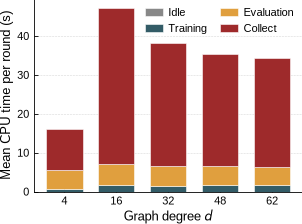

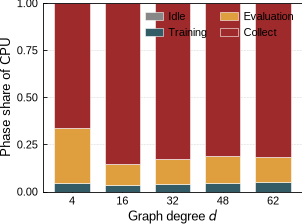

In [2]:
DEGREE_VALUES = [4, 16, 32, 48, 62]
deg_agg = {d: {0: [], 1: [], "eval": [], 3: []} for d in DEGREE_VALUES}
n_rounds_at = {}

for name, path in list_runs("../metrics/b1_degree_sweep"):
    config = read_config_from_csv(path)
    if config.get("topology_type") != "circulant":
        continue

    degree = int(config["graph_degree"])
    if degree not in deg_agg:
        continue

    n_rounds_at[degree] = int(config["n_rounds"])

    df = clip_to_n_rounds(from_round_one(load_file(path)), int(config["n_rounds"]))

    for node, df_node in df.groupby("node"):

        cpu_per_phase = per_phase_cpu(df_node)
        deg_agg[degree][0].append(cpu_per_phase[0])
        deg_agg[degree][1].append(cpu_per_phase[1])
        deg_agg[degree]["eval"].append(cpu_per_phase[2] + cpu_per_phase[4])
        deg_agg[degree][3].append(cpu_per_phase[3])

deg_means = {d: {p: float(np.mean(v)) for p, v in row.items()} for d, row in deg_agg.items()}
deg_means_per_round = {d: {p: deg_means[d][p] / n_rounds_at[d] for p in [0, 1, "eval", 3]} for d in DEGREE_VALUES}

deg_totals = {d: sum(deg_means[d].values()) for d in DEGREE_VALUES}
deg_shares = {d: {p: deg_means[d][p] / deg_totals[d] for p in [0, 1, "eval", 3]} for d in DEGREE_VALUES}

x_values = np.arange(len(DEGREE_VALUES))

fig_abs, ax_abs = plt.subplots(figsize=FIGURE_SIZE_HALF)
bottom_abs = np.zeros(len(DEGREE_VALUES))

for p in [0, 1, "eval", 3]:
    bar_heights = np.array([deg_means_per_round.get(d, {}).get(p, 0.0) for d in DEGREE_VALUES])
    ax_abs.bar(
        x_values,
        bar_heights,
        bottom=bottom_abs,
        color=PHASE_COLORS[p],
        label=PHASE_LABELS[p],
        width=0.7,
        edgecolor="white",
        linewidth=0.4,
    )
    bottom_abs += bar_heights

ax_abs.set_xticks(x_values)
ax_abs.set_xticklabels([str(d) for d in DEGREE_VALUES])
ax_abs.set_xlabel(r"Graph degree $d$")
ax_abs.set_ylabel("Mean CPU time per round (s)")
ax_abs.grid(axis="y", **GRID_STYLE)
ax_abs.legend(loc="upper right", frameon=False, ncol=2)

plt.tight_layout()

save_figure(fig_abs, f"{FIG_DIR}/cpu_per_phase_stacked_by_degree_abs.pdf")
plt.show()

fig_share, ax_share = plt.subplots(figsize=FIGURE_SIZE_HALF)
bottom_rel = np.zeros(len(DEGREE_VALUES))
for p in [0, 1, "eval", 3]:

    bar_heights = np.array([deg_shares[d][p] for d in DEGREE_VALUES])

    ax_share.bar(
        x_values,
        bar_heights,
        bottom=bottom_rel,
        color=PHASE_COLORS[p],
        label=PHASE_LABELS[p],
        width=0.7,
        edgecolor="white",
        linewidth=0.4,
    )
    bottom_rel += bar_heights

ax_share.set_xticks(x_values)
ax_share.set_xticklabels([str(d) for d in DEGREE_VALUES])
ax_share.set_xlabel(r"Graph degree $d$")
ax_share.set_ylabel("Phase share of CPU")
ax_share.set_ylim(0, 1.0)
ax_share.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])

ax_share.grid(axis="y", **GRID_STYLE)

ax_share.legend(loc="upper right", frameon=False, ncol=2)
plt.tight_layout()

save_figure(fig_share, f"{FIG_DIR}/cpu_per_phase_stacked_by_degree_share.pdf")
plt.show()

In [3]:
DEGREE_DIR = "../metrics/b1_degree_sweep"
SQZ_DEGREE_DIR = "../metrics/b2_squeezenet_degree_sweep_n64"

TOPO_COLORS = {
    "circulant": slate_teal,
    "ring_lattice": deep_red,
}

CPU_LABEL = "Mean CPU time per round (s)"
MEM_LABEL = "Mean memory per node (MB)"


def band(ax, x_values, series, color, linestyle="-"):
    ys_mean = [float(np.mean(series[x])) for x in x_values]
    ys_lo = [float(np.min(series[x])) for x in x_values]
    ys_hi = [float(np.max(series[x])) for x in x_values]

    ax.plot(x_values, ys_mean, color=color, linewidth=1.2, linestyle=linestyle, **MARKER_STYLE)
    ax.fill_between(x_values, ys_lo, ys_hi, color=color, alpha=0.2, linewidth=0)

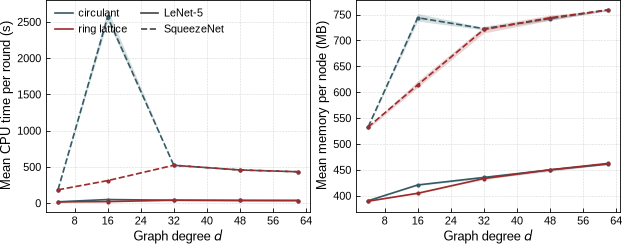

In [4]:
cpu_by_topo = {"circulant": {}, "ring_lattice": {}}
mem_by_topo = {"circulant": {}, "ring_lattice": {}}
cpu_by_topo_sqz = {"circulant": {}, "ring_lattice": {}}
mem_by_topo_sqz = {"circulant": {}, "ring_lattice": {}}


def collect_degree(base_dir, cpu_dst, mem_dst):
    for name, path in list_runs(base_dir):
        config = read_config_from_csv(path)
        topo = config.get("topology_type")
        if topo not in cpu_dst:
            continue

        degree = int(config["graph_degree"])
        n_rounds = int(config["n_rounds"])

        df = from_round_one(load_file(path))
        cpu_seconds = cpu_seconds_per_round_per_node(df, n_rounds)
        memory = mean_memory_per_node(df)

        if degree not in cpu_dst[topo]:
            cpu_dst[topo][degree] = []
        cpu_dst[topo][degree].append(float(np.mean(cpu_seconds)))

        if degree not in mem_dst[topo]:
            mem_dst[topo][degree] = []
        mem_dst[topo][degree].append(float(np.mean(memory)))


collect_degree(DEGREE_DIR, cpu_by_topo, mem_by_topo)
collect_degree(SQZ_DEGREE_DIR, cpu_by_topo_sqz, mem_by_topo_sqz)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)
for topo in ["circulant", "ring_lattice"]:

    x_values = sorted(cpu_by_topo[topo])
    band(axes[0], x_values, cpu_by_topo[topo], TOPO_COLORS[topo])
    band(axes[1], x_values, mem_by_topo[topo], TOPO_COLORS[topo])

    x_values_sqz = sorted(cpu_by_topo_sqz[topo])
    band(axes[0], x_values_sqz, cpu_by_topo_sqz[topo], TOPO_COLORS[topo], linestyle="--")
    band(axes[1], x_values_sqz, mem_by_topo_sqz[topo], TOPO_COLORS[topo], linestyle="--")

    axes[0].plot([], [], color=TOPO_COLORS[topo], label=topo.replace("_", " "), **LINE_STYLE)

axes[0].plot([], [], color=dark_grey, label="LeNet-5", linewidth=1.2, linestyle="-")
axes[0].plot([], [], color=dark_grey, label="SqueezeNet", linewidth=1.2, linestyle="--")

all_mem = []
for topo in ["circulant", "ring_lattice"]:
    all_mem += [float(np.mean(v)) for v in mem_by_topo[topo].values()]
    all_mem += [float(np.mean(v)) for v in mem_by_topo_sqz[topo].values()]
axes[1].set_ylim(min(all_mem) - 20, max(all_mem) + 20)

for ax in axes:
    ax.set_xlabel(r"Graph degree $d$")
    ax.grid(**GRID_STYLE)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0].set_ylabel(CPU_LABEL)
axes[1].set_ylabel(MEM_LABEL)
axes[0].legend(loc="upper left", frameon=False, ncol=2)
plt.tight_layout()
save_figure(fig, f"{FIG_DIR}/cpu_memory_vs_degree.pdf")
plt.show()

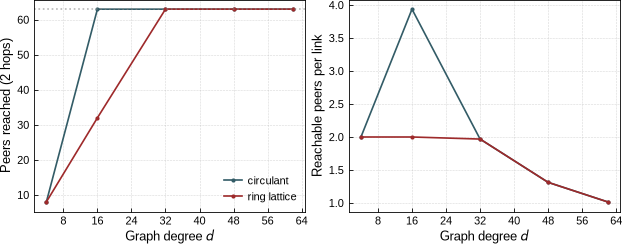

In [5]:
import sys

if ".." not in sys.path:
    sys.path.insert(0, "..")
import networkx as nx
from manager.services.topology_service import compute_circulant_params, exchange_target_count, _nx_to_adj

REACH_N = 64


def reach_at(topo, d):
    offsets = compute_circulant_params(REACH_N, d)[0] if topo == "circulant" else list(range(1, d // 2 + 1))
    return exchange_target_count(_nx_to_adj(nx.circulant_graph(REACH_N, offsets)), 2, True)


reach = {t: [reach_at(t, d) for d in DEGREE_VALUES] for t in ("circulant", "ring_lattice")}
fanin = {t: [reach[t][i] / DEGREE_VALUES[i] for i in range(len(DEGREE_VALUES))] for t in reach}

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)
for topo in ("circulant", "ring_lattice"):

    axes[0].plot(
        DEGREE_VALUES, reach[topo], color=TOPO_COLORS[topo], label=topo.replace("_", " "), **LINE_STYLE, **MARKER_STYLE
    )

    axes[1].plot(DEGREE_VALUES, fanin[topo], color=TOPO_COLORS[topo], **LINE_STYLE, **MARKER_STYLE)

axes[0].axhline(REACH_N - 1, **EVENT_BOUNDARY_STYLE)
axes[0].set_ylabel("Peers reached (2 hops)")
axes[1].set_ylabel("Reachable peers per link")

for ax in axes:
    ax.set_xlabel(r"Graph degree $d$")
    ax.grid(**GRID_STYLE)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

axes[0].legend(loc="lower right", frameon=False)
plt.tight_layout()

save_figure(fig, f"{FIG_DIR}/reach_fanin_by_degree.pdf")

plt.show()